<a href="https://colab.research.google.com/github/Utkarsha1407/DSBDA-Practical/blob/main/AirQuality_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


In [ ]:
data = pd.read_csv("/content/AirQuality_visualization - AirQuality_visualization.csv")

In [ ]:
data.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360,150,"11,9",1046,166,1056,113,1692,1268,"13,6","48,9","7,578"
1,10/03/2004,19.00.00,2,1292,112,"9,4",955,103,1174,92,1559,972,"13,3","47,7","7,255"
2,10/03/2004,20.00.00,"2,2",1402,88,"9,0",939,131,1140,114,1555,1074,"11,9","54,0","7,502"
3,10/03/2004,21.00.00,"2,2",1376,80,"9,2",948,172,1092,122,1584,1203,"11,0","60,0","7,867"
4,10/03/2004,22.00.00,"1,6",1272,51,"6,5",836,131,1205,116,1490,1110,"11,2","59,6","7,888"


In [ ]:
df.shape

(8911, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8911 entries, 0 to 8910
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   CO(GT)         8911 non-null   float64 
 1   PT08.S1(CO)    8911 non-null   float64 
 2   NMHC(GT)       8911 non-null   float64 
 3   C6H6(GT)       8911 non-null   float64 
 4   PT08.S2(NMHC)  8911 non-null   float64 
 5   NOx(GT)        8911 non-null   float64 
 6   PT08.S3(NOx)   8911 non-null   float64 
 7   NO2(GT)        8911 non-null   float64 
 8   PT08.S4(NO2)   8911 non-null   float64 
 9   PT08.S5(O3)    8911 non-null   float64 
 10  T              8911 non-null   float64 
 11  RH             8911 non-null   float64 
 12  AH             8911 non-null   float64 
 13  AH_Category    8911 non-null   category
dtypes: category(1), float64(13)
memory usage: 914.0 KB


In [ ]:

df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,8.911000e+03,8.911000e+03,8.911000e+03,8.911000e+03,8.911000e+03,8.911000e+03,8.911000e+03,8.911000e+03,8.911000e+03,8.911000e+03,8.911000e+03,8.911000e+03,8.911000e+03
mean,-8.930624e-17,-2.009390e-16,2.806767e-16,5.581640e-17,1.674492e-16,-1.020643e-16,-3.827410e-17,-5.741115e-17,-3.444669e-16,9.728001e-17,4.465312e-17,3.205456e-16,5.741115e-17
std,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00
min,-1.594665e+00,-3.348327e+00,-3.342701e-01,-2.208541e+00,-2.873758e+00,-1.489470e+00,-2.769269e+00,-1.668202e+00,-3.110518e+00,-2.508774e+00,-2.161260e+00,-2.327709e+00,-2.226102e+00
25%,-3.147384e-01,-4.873166e-01,-3.342701e-01,-6.401024e-01,-6.087535e-01,-4.445753e-01,-5.427863e-01,-4.791832e-01,-5.100804e-01,-6.182410e-01,-6.928802e-01,-7.171922e-01,-6.873779e-01
50%,-1.529333e-02,-2.871574e-02,-3.342701e-01,-2.519667e-01,-1.906819e-02,-7.668092e-02,-3.622839e-02,8.975749e-02,1.074199e-01,-6.390724e-02,-1.209891e-01,-1.532691e-02,-1.069368e-01
75%,4.565823e-01,5.756675e-01,-3.342701e-01,4.768396e-01,6.708835e-01,4.819900e-01,5.141841e-01,6.152210e-01,6.184563e-01,6.306395e-01,6.328271e-01,7.420984e-01,6.466506e-01
max,3.852780e+00,3.210768e+00,3.212985e+00,3.621258e+00,2.317287e+00,4.382363e+00,6.461451e+00,3.942972e+00,2.895499e+00,3.629001e+00,2.718526e+00,2.072428e+00,2.694217e+00


In [ ]:
df.isnull().sum()

,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0
PT08.S4(NO2),0
PT08.S5(O3),0


In [ ]:
print(df.duplicated().sum())

31


In [ ]:
df.columns

Index(['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
       'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
       'T', 'RH', 'AH', 'AH_Category'],
      dtype='object')

In [ ]:
df.shape

(8911, 14)

Data cleaning

In [ ]:
cols_to_fix =['CO(GT)','C6H6(GT)','T','RH','AH']
for col in cols_to_fix:
    data[col]=data[col].str.replace(',','.')
    data[col]=data[col].astype(float)

In [ ]:
data

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,7.578
1,10/03/2004,19.00.00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,7.255
2,10/03/2004,20.00.00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,7.502
3,10/03/2004,21.00.00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,7.867
4,10/03/2004,22.00.00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,7.888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,7.568
9353,04/04/2005,11.00.00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,7.119
9354,04/04/2005,12.00.00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,6.406
9355,04/04/2005,13.00.00,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.3,13.5,5.139


In [ ]:
data = data.astype({
    'CO(GT)': 'float64',
    'C6H6(GT)': 'float64',
    'T': 'float64',
    'RH': 'float64',
    'AH': 'float64'
})

In [ ]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


In [ ]:
data.dropna(inplace=True)

In [ ]:
data.drop_duplicates(inplace=True,ignore_index=True)

DATA INTEGRATION

In [ ]:
subset1 = data[['Date','Time']]
subset2 = data[['T','RH']]

In [ ]:
integrated = pd.concat([subset1, subset2], axis = 1)
print(integrated)

            Date      Time     T    RH
0     10/03/2004  18.00.00  13.6  48.9
1     10/03/2004  19.00.00  13.3  47.7
2     10/03/2004  20.00.00  11.9  54.0
3     10/03/2004  21.00.00  11.0  60.0
4     10/03/2004  22.00.00  11.2  59.6
...          ...       ...   ...   ...
9352  04/04/2005  10.00.00  21.9  29.3
9353  04/04/2005  11.00.00  24.3  23.7
9354  04/04/2005  12.00.00  26.9  18.3
9355  04/04/2005  13.00.00  28.3  13.5
9356  04/04/2005  14.00.00  28.5  13.1

[9357 rows x 4 columns]


DATA TRANSFORMATION

In [ ]:
def remove_outliers(data,column,lower=0.01,upper=0.99):
      low=data[column].quantile(lower)
      high=data[column].quantile(upper)
      return data[(data[column]>=low) & (data[column]<=high)]

In [ ]:
df = data.copy()

for col in ['CO(GT)','C6H6(GT)','T','RH','AH']:
    df = remove_outliers(df, col)

df = df.reset_index(drop=True)

In [ ]:
df.drop(columns=['Date','Time'], inplace=True, errors='ignore')

In [ ]:
pt = PowerTransformer(method='yeo-johnson')
df = pd.DataFrame(pt.fit_transform(df), columns=df.columns)


ERROR CORRECTING

In [ ]:


print(df.isnull().sum())


CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [ ]:
print(df.duplicated().sum())

31


In [ ]:
print(data.duplicated().sum())

0


DATA VISUALIZATION

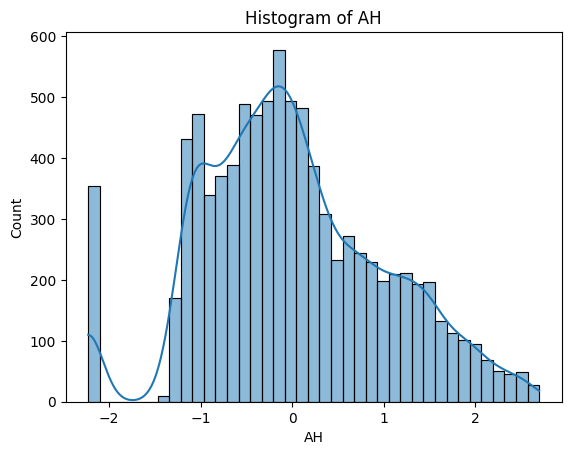

In [ ]:
sns.histplot(df['AH'], kde=True)
plt.title("Histogram of AH")
plt.show()

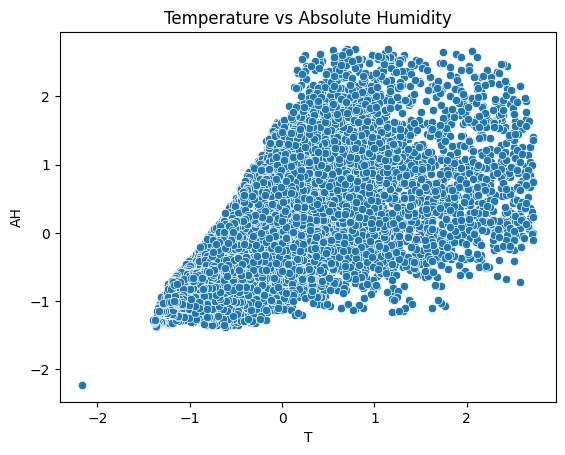

In [ ]:
sns.scatterplot(x=df['T'], y=df['AH'])
plt.title("Temperature vs Absolute Humidity")
plt.show()

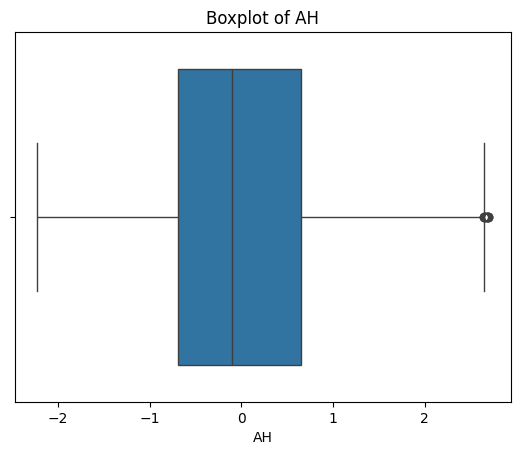

In [ ]:
sns.boxplot(x=df['AH'])
plt.title("Boxplot of AH")
plt.show()

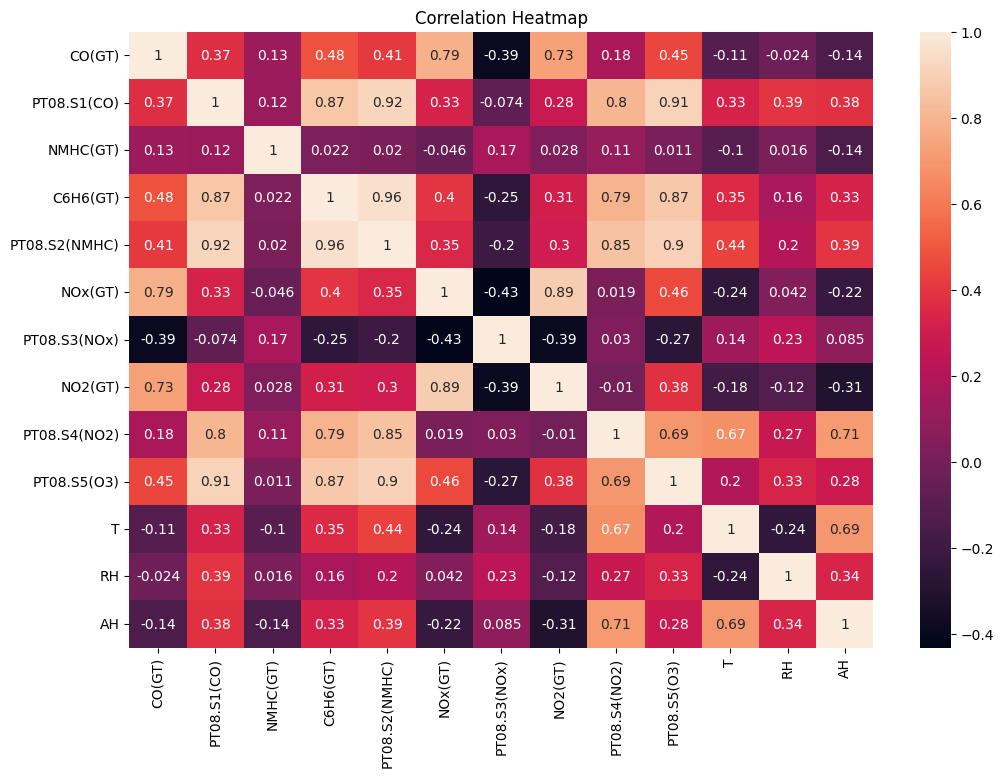

In [ ]:
df_numeric = df.select_dtypes(include='number')

plt.figure(figsize=(12,8))
sns.heatmap(df_numeric.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

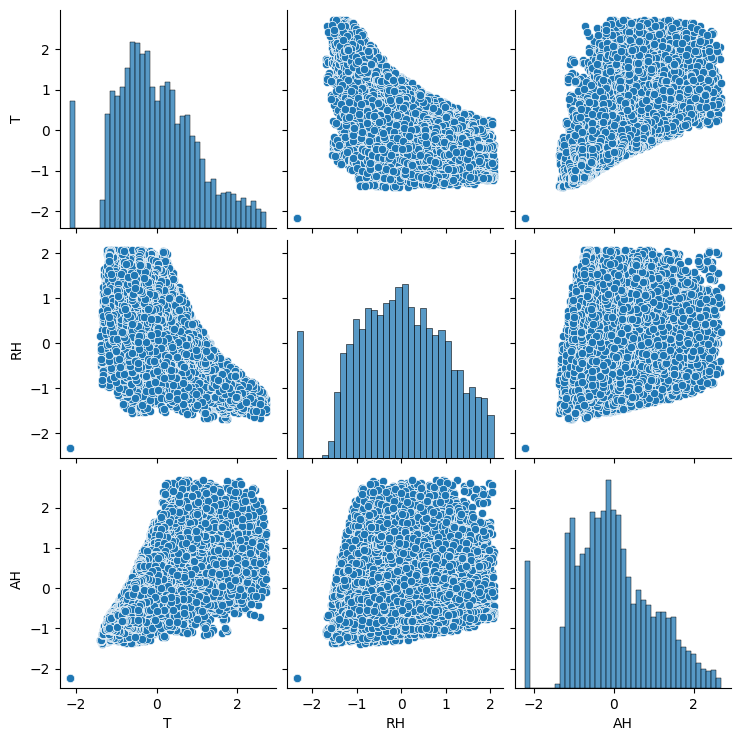

In [ ]:
sns.pairplot(df[['T','RH','AH']])
plt.show()

MODEL BUILDING

In [ ]:
X = df.drop('AH', axis=1)
y = df['AH']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lr = LinearRegression()


In [ ]:
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
lr_pred = lr.predict(X_test)

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [ ]:
print("Linear Regression")
print("R2:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))

Linear Regression
R2: 0.8656215543626373
MAE: 0.28541331247926705
MSE: 0.1373279375639945


In [ ]:
print("\nDecision Tree")
print("R2:", r2_score(y_test, dt_pred))
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("MSE:", mean_squared_error(y_test, dt_pred))


Decision Tree
R2: 0.9952367547833375
MAE: 0.045095453939809745
MSE: 0.0048677943744123145
